Testing whether increasing the number of steps in halo mass fixes the bumps in the UVLF

In [3]:
from escripts import eMCMC
from escripts import eplots
from escripts import edata
import zeus21

In [4]:
# Get data
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt',
               '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt']
data_labels = ['Bouwens+21', 'Donnan+24']
sorted_data = edata.get_sorted(file_names, data_labels)

In [5]:
param_dict = eMCMC.build_param_data({'min_sig':{'value':0}})

In [96]:
precision_boosts = np.arange(2.7, 3.7, 0.1)

In [97]:
UVLFs = [eMCMC.UVLF(sorted_data, param_dict, precisionboost = pb) for pb in precision_boosts]

In [98]:
std_model = [0.549, -0.947, 12.059, -0.745, .1]

In [99]:
z = 4
deltaz = 0.5

In [100]:
MUVbins, MUVwidths = UVLFs[0].get_all_MUV_bins()

In [101]:
UVLF_plot = [UVLF.UVLF_wrapper(z, deltaz, MUVbins, MUVwidths, std_model) for UVLF in UVLFs]

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude


Text(0.5, 1.0, '$\\sigma_{\\rm{UV}} =$0.1')

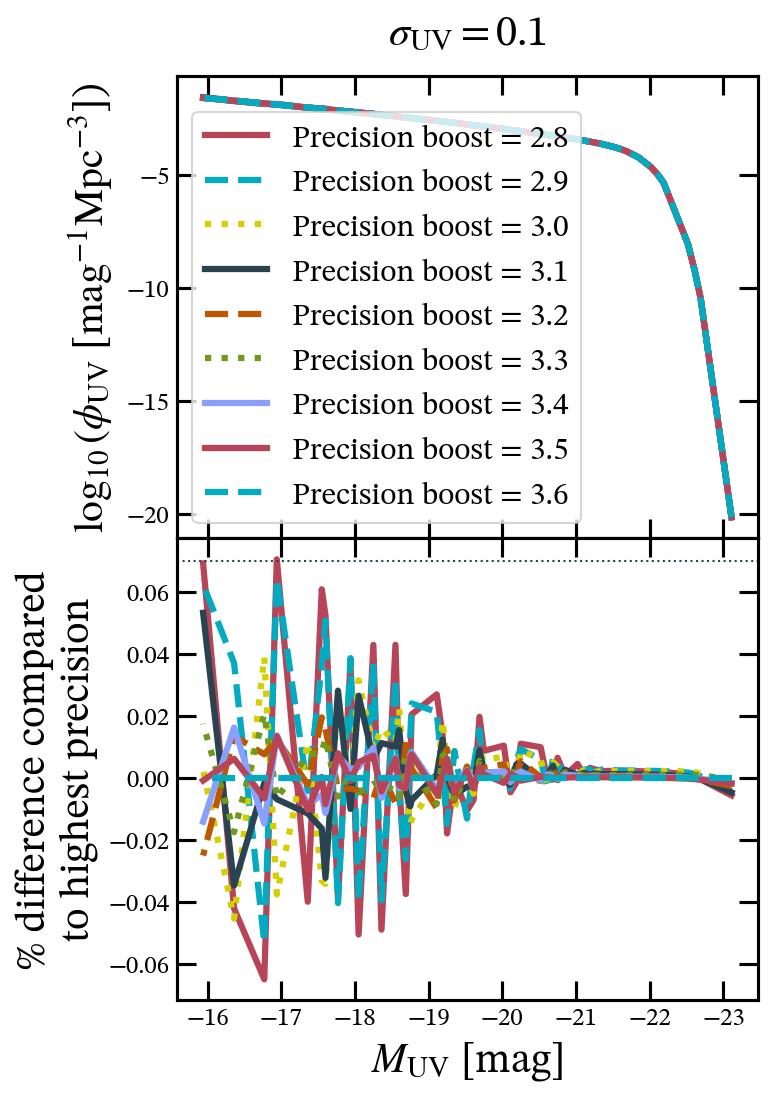

In [107]:
fig, ax = plt.subplots(2, 1, sharex = True)
fig.set_size_inches(5, 8)
plt.subplots_adjust(hspace = 0)
for y, pb in zip(UVLF_plot[1:], precision_boosts[1:]):
    ax[0].plot(MUVbins, np.log10(y), label = f'Precision boost = {round(pb, 3)}')
    ax[1].plot(MUVbins, (y - UVLF_plot[-1])/UVLF_plot[-1])

ax[1].axhline(0.07, ls = 'dotted', color = eplots.navy, lw = 1)

ax[0].set_ylabel(r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])')
ax[1].set_xlabel(r'$M_{\rm{UV}}$ [mag]')
ax[1].set_ylabel(f'% difference compared\nto highest precision')
ax[0].invert_xaxis()
ax[0].legend()
ax[0].set_title(r'$\sigma_{\rm{UV}} =$' + f'{std_model[-1]}')

In [94]:
fig.savefig('/Users/eb35267/Desktop/code/figures/hmf_convergence.png')

In [109]:
minsig = np.arange(0.1, 0.8, 0.1)
convergence = [2.9, 1.95, 1.95, 1.2, 1.1, 1.1, 1]

In [195]:
from scipy.optimize import minimize

def quantile_loss(params, x, y, model_func, q=1.0):
    residuals = y - model_func(x, *params)
    return np.sum(np.where(residuals >= 0, q * residuals, (q - 1) * residuals))

def your_model_func(x, a, b, c):
    return a*x**b + c
result = minimize(quantile_loss, x0=[1, 1, 1], args=(minsig, convergence, your_model_func, 0.88))

In [ ]:
result.x

array([-4.29891084,  0.36442289,  4.75752874])

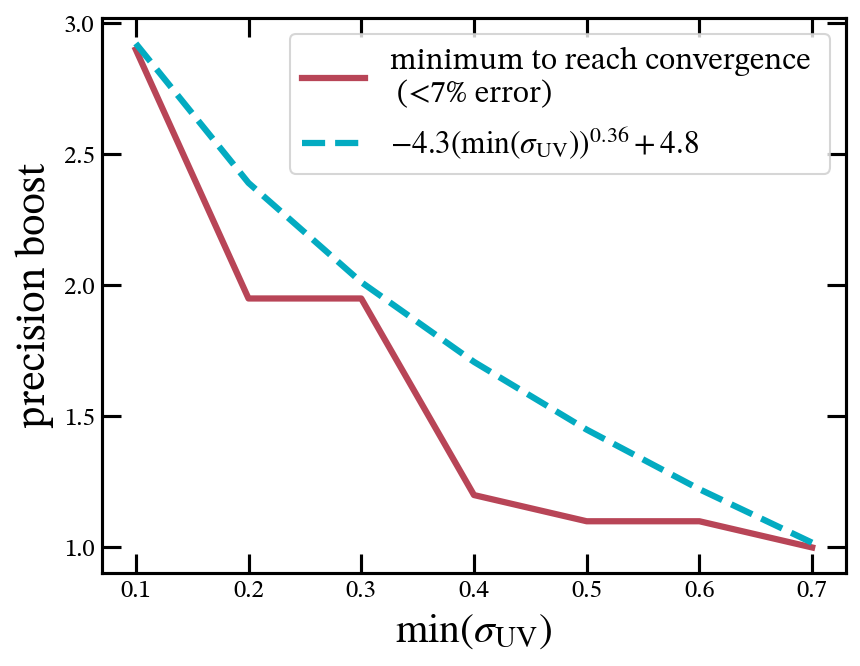

In [231]:
fig, ax = plt.subplots()
ax.plot(minsig, convergence, label = 'minimum to reach convergence \n (<7% error)')
ax.plot(minsig, your_model_func(minsig, *[-4.3, 0.36, 4.8]), label = r'$-4.3(\min(\sigma_{\rm{UV}}))^{0.36} + 4.8$')

ax.set_xlabel(r'$\min(\sigma_{\rm{UV}})$')
ax.set_ylabel('precision boost')

ax.legend()

In [232]:
fig.savefig('/Users/eb35267/Desktop/code/figures/convergence_limit.png')

In [236]:
your_model_func(0.05, *[-4.3, 0.36, 4.8])

3.337493997746982

# Old stuff

In [35]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_fixed.txt', 
              '/Users/eb35267/Desktop/code/home/data/Donnan24_GAL.txt',
             '/Users/eb35267/Desktop/code/home/data/Mcleod_24.txt']
data_labels = ['Bouwens+21', 'Donnan+24', 'McLeod+24']
sorted_data = edata.get_sorted(file_names, data_labels)

In [40]:
params = eMCMC.build_param_data({})

In [51]:
importlib.reload(eMCMC)

<module 'escripts.eMCMC' from '/Users/eb35267/Desktop/code/home/escripts/eMCMC.py'>

In [52]:
my_UVLF_og = eMCMC.UVLF(sorted_data, params)

In [119]:
fully_boosted = eMCMC.UVLF(sorted_data, params, precisionboost = 2)

In [134]:
precisionboost = 1.5
my_UVLF_boosted = eMCMC.UVLF(sorted_data, params, precisionboost = precisionboost)

In [135]:
fit = [0.7, 0, -0.7, 0.41, 13.96, -0.38, -0.59, 0.29, 0, 0.05, 1]

Skipping $z=4.0$
Skipping $z=5.0$
Skipping $z=6.0$
Skipping $z=8.0$
Skipping $z=9.0$
Skipping $z=10.0$
Skipping $z=11.0$
Skipping $z=12.5$
Skipping $z=13.5$
Skipping $z=14.5$


Text(0.5, 1.0, 'Example UVLF')

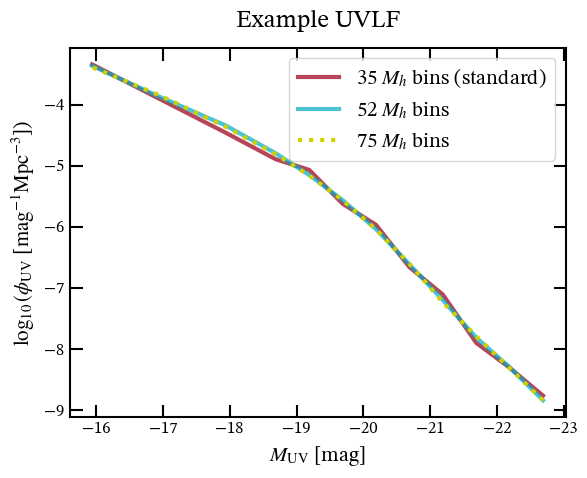

In [137]:
z_plot = [7]
fig, ax = plt.subplots()
plot_xdat, plot_xerr = my_UVLF_og.data[0][2], my_UVLF_og.data[0][5] # Use the lowest redshift MUV centers & bins as the grid to calculate the
                                                                # theoretical UVLF on
i = 0 # Can't use enumerate because we're allowing for the possibility that the user will want to skip certain z bins 
for zbin in my_UVLF_og.sorted_data:

    zdat, zerr = zbin[0][0], zbin[0][1]

    if zdat not in z_plot:
        print(f'Skipping $z={zdat}$')
        continue

    ax.plot(plot_xdat, np.log10(my_UVLF_og.UVLF_wrapper(zdat,zerr,plot_xdat,plot_xerr,fit)), label = r'35 $M_h$ bins (standard)')
    ax.plot(plot_xdat, np.log10(my_UVLF_boosted.UVLF_wrapper(zdat,zerr,plot_xdat,plot_xerr,fit)), 
            label = f'{int(precisionboost * 35)} $M_h$ bins', ls = '-', alpha = 0.7)
    ax.plot(plot_xdat, np.log10(fully_boosted.UVLF_wrapper(zdat,zerr,plot_xdat,plot_xerr,fit)), 
            label = f'75 $M_h$ bins', ls = 'dotted')

ax.invert_xaxis()
ylabel = r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])'
xlabel = r'$M_{\rm{UV}}$ [mag]'
ax.set_ylabel(ylabel)
ax.set_xlabel(xlabel)
ax.legend()
ax.set_title('Example UVLF')

In [138]:
fig.savefig('/Users/eb35267/Desktop/code/figures/HMF_resolution.png')